In [26]:
import matplotlib.image as mpimg
import time
import numpy as np
import matplotlib.pyplot as plt
import math
from numba import cuda, float32

In [30]:
GAUSSIAN_KERNEL = np.array([
    [0, 0, 1, 2, 1, 0, 0],
    [0, 3, 13, 22, 13, 3, 0],
    [1, 13, 59, 97, 59, 13, 1],
    [2, 22, 97, 159, 97, 22, 2],
    [1, 13, 59, 97, 59, 13, 1],
    [0, 3, 13, 22, 13, 3, 0],
    [0, 0, 1, 2, 1, 0, 0]
], dtype=np.float32)
# Norm kernel
GAUSSIAN_KERNEL = GAUSSIAN_KERNEL / np.sum(GAUSSIAN_KERNEL)

KERNEL_SIZE = 7
PAD = KERNEL_SIZE // 2
BLOCK_SIZE = 16
TILE_SIZE = BLOCK_SIZE + 2 * PAD  # block's pixels + halo on each side

In [12]:
# Read image
img = mpimg.imread('original_image.jpg')

# CPU Version

CPU processing time: 174.747945 seconds


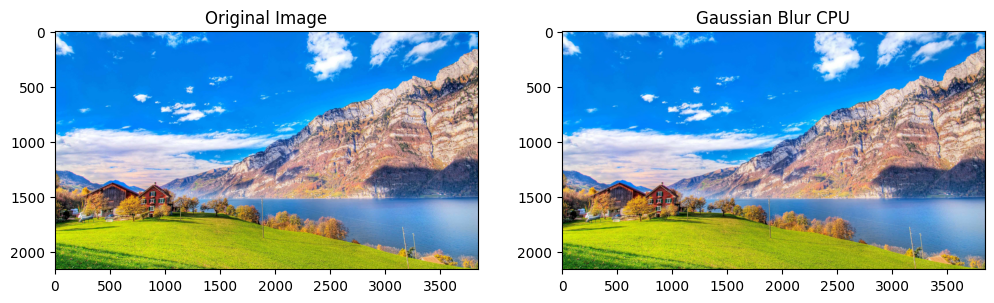

In [16]:
#Gaussian blur
def gaussian_blur(image):
    start = time.time()
    height, width, channels = image.shape

    # Convert image to float
    image = image.astype(np.float32)

    # Padding image
    padded = np.pad(
        image,
        ((PAD, PAD), (PAD, PAD), (0, 0)),
        mode='constant'
    )

    # Create output image
    output = np.zeros_like(image)

    # Convolution
    for y in range(height):
        for x in range(width):
            for c in range(channels):
                region = padded[
                    y:y + KERNEL_SIZE,
                    x:x + KERNEL_SIZE,
                    c
                ]
                output[y, x, c] = np.sum(region * GAUSSIAN_KERNEL)

    end = time.time()
    print(f"CPU processing time: {end - start:.6f} seconds")

    return np.clip(output, 0, 255).astype(np.uint8)



# Apply Gaussian blur
blurred = gaussian_blur(img)

# Display results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(blurred)
plt.title("Gaussian Blur CPU")

plt.show()

# GPU Gaussian blur without shared memory

Blocks per grid: (68, 120)
GPU processing time without shared memory: 0.713428 seconds


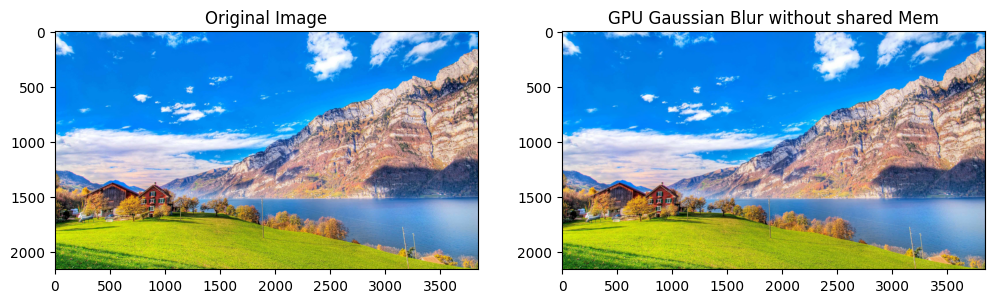

In [25]:
# CUDA Kernel: Gaussian Blur Without Shared Memory
@cuda.jit
def gaussian_blur_kernel(src, dst, kernel, height, width, channels):
    y, x = cuda.grid(2)

    # Local memory for RGB channels
    value = cuda.local.array(3, dtype=float32)
    for c in range(channels):
        value[c] = 0.0

    # Convolution
    for ky in range(KERNEL_SIZE):
        for kx in range(KERNEL_SIZE):

            iy = y + ky - PAD
            ix = x + kx - PAD

            # If neighborhood inside the image boundary
            if 0 <= iy < height and 0 <= ix < width:
                for c in range(channels):
                    value[c] += (src[iy, ix, c] * kernel[ky, kx])

    for c in range(channels):
        dst[y, x, c] = value[c]

def gaussian_blur_gpu(img):
    start = time.time()
    height, width, channels = img.shape

    # Convert image to float32
    img = img.astype(np.float32)

    # Create output image
    dst_host = np.zeros_like(img)

    # Transfer data to GPU
    d_src = cuda.to_device(img)
    d_dst = cuda.to_device(dst_host)
    d_kernel = cuda.to_device(GAUSSIAN_KERNEL)

    # CUDA configuration
    threads_per_block = (BLOCK_SIZE, BLOCK_SIZE)

    blocks_per_grid = ((height + threads_per_block[0] - 1) // threads_per_block[0],
                        (width + threads_per_block[1] - 1)// threads_per_block[1])
    print("Blocks per grid:", blocks_per_grid)

    # Launch CUDA kernel
    gaussian_blur_kernel[blocks_per_grid, threads_per_block](
        d_src,
        d_dst,
        d_kernel,
        height,
        width,
        channels,
    )

    # Synchronize GPU
    cuda.synchronize()

    # Copy result back to CPU
    dst_host = d_dst.copy_to_host()

    end = time.time()

    print(f"GPU processing time without shared memory: {end - start:.6f} seconds")

    return dst_host

# Run
output = gaussian_blur_gpu(img)
output_display = np.clip(output, 0, 255).astype(np.uint8)

# Display results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(output_display)
plt.title("GPU Gaussian Blur without shared Mem")

plt.show()

# Gaussian Blur With Shared Memory

GPU (shared memory) time: 0.4778s


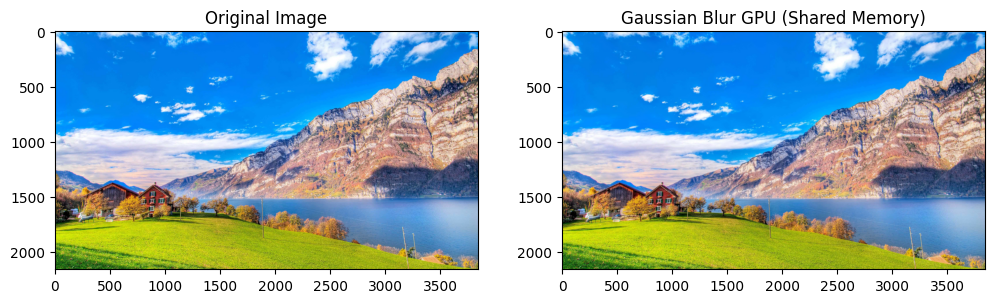

In [34]:
@cuda.jit
def gaussian_blur_gpu_shared(src, dst, kernel):
    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

    h, w, _ = src.shape

    tile = cuda.shared.array((TILE_SIZE, TILE_SIZE, 3), float32)

    for ly in range(ty, TILE_SIZE, BLOCK_SIZE):
        gy = min(max(cuda.blockIdx.y * BLOCK_SIZE + ly - PAD, 0), h - 1)
        for lx in range(tx, TILE_SIZE, BLOCK_SIZE):
            gx = min(max(cuda.blockIdx.x * BLOCK_SIZE + lx - PAD, 0), w - 1)
            for c in range(3):
                tile[ly, lx, c] = src[gy, gx, c]

    cuda.syncthreads()

    if x < w and y < h:
        for c in range(3):
            acc = 0.0
            for ky in range(KERNEL_SIZE):
                for kx in range(KERNEL_SIZE):
                    acc += tile[ty + ky, tx + kx, c] * kernel[ky, kx]
            dst[y, x, c] = acc


def gaussian_blur_gpu(image):
    h, w, c = image.shape
    src = np.ascontiguousarray(image.astype(np.float32))

    d_src = cuda.to_device(src)
    d_kernel = cuda.to_device(GAUSSIAN_KERNEL)
    d_dst = cuda.device_array_like(src)

    grid_size = (math.ceil(w / BLOCK_SIZE), math.ceil(h / BLOCK_SIZE))
    block_size = (BLOCK_SIZE, BLOCK_SIZE)

    start = time.time()
    gaussian_blur_gpu_shared[grid_size, block_size](d_src, d_dst, d_kernel)
    cuda.synchronize()
    elapsed = time.time() - start

    output = d_dst.copy_to_host()
    return np.clip(output, 0, 255).astype(np.uint8), elapsed


# Run GPU Gaussian blur (shared memory)
img = mpimg.imread('original_image.jpg')
blurred_gpu, gpu_time = gaussian_blur_gpu(img)
print(f"GPU (shared memory) time: {gpu_time:.4f}s")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(blurred_gpu)
plt.title("Gaussian Blur GPU (Shared Memory)")

plt.show()